### Analisis de procesamiento de señales - UNSAM <img src=./logo_UNSAM.jpg align=right width=150>
## TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo
### Lanzavechia, Jerónimo

Aclaracion: El formateo de los gráficos y las porciones del documento en Latex se hicieron con Chat-GPT 

## Introducción
Durante las ultimas tareas semanales, al realizar una Transformada de Fourier de una función, se tomaban muestras de la señal a lo largo del tiempo y se obtienía el espectro de densidad de potencia con respecto a un dominio discreto de la frecuencia. Ese muestreo en frecuencia se realiza en porciones del espectro. Cada una de estas porciones es un bin. La porción del tiempo en la que analizamos una señal es una "ventana". Hasta el momento, esa ventana estaba implicita en nuestras funciones, pero nunca se prestó atención a dicha ventana en los analisis. La ventana implicita es una "boxcar" (caja rectangular) que ocupa exactamente el tiempo de muestreo. 

Al mismo tiempo, todas las señales analizadas tenuian frecuencias enteras. Dichas señales, dentro de una ventana, mostraban un espectro que correspondia a un delta en su frecuencia de oscilación. 

Sucede que como el dominio de frecuencias usado hasta el momento no era continuo, lo que realmente se estaba haciendo era una DFT (Transformada discreta de Fourier) usando la FFT (Transformada Rapida de Fourier) de la libreria Scipy. 
Una de las propiedades de la DFT es que al hacer la transformada inversa de un producto en el dominio de la frecuencia, se hace convolución circular en el tiempo discreto. 

Una convolución circular entre la ventana implicita y un ciclo de una senoidal daría por resultado algo que se repite en el dominio del tiempo cada tantas muestras, y como una senoidal es periódica, veriamos un periodo que se repite a lo largo del tiempo. Es de interes para este trabajo estudiar que pasaria si dichas señales no diesen ciclos completos, o sumaran porciones incompletas de siguientes ciclos dentro de la ventana.

En este trabajo se estudiaran señales con frecuencias ligeramente desplazadas de una central y se analizarán que efectos tienen en el espectro: el desparramo espectral. Tambien se estudiará el efecto del zero padding, y como influye esto en el espectro de la señal. 

## Desarrollo

Se sabe que para una DFT, se hace la transformada de la convolución circular de una señal por una ventana:

\begin{align}
x[n] = x[n]*[n] = X'[n]
\end{align}

$x[n]$ : Señal muestreada  
$r[n]$ : Ventana muestreada  
$X'[n]$ : Producto de la ventana por la señal

Si se analiza una señal cuadrada a traves de una fft, se obtiene una Sinc(w) centrada en el espectro con sus lobulos menores hacia los costados. Si esta es la ventana implicita, lo que se ve en la dft es el producto en frecuencia de la Sinc(w) con la transformada de la señal. Hasta ahora, se probó con señales periódicas dentro de la boxcar, nunca con señales de frecuencia que no se volvieran a juntar en sus extremos. 

Se resuelven los puntos dados en la consigna de la TS3. 
Se pide graficar las densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de agregar desintonías en el espectro visualizado. Luego verificar la potencia unitaria de cada PSD y discutir las diferencias entre espectros para tan pocos Hz (Hertz) de diferencia.
Por último, se pide repetir el experimento mediante la técnica de zero padding, agregando ceros al final de la señal para aumentar el bin de forma ficticia y discutir los resultados obtenidos.

Para verificar la potencia de las senoidales, se hará por la identidad de parseval:

\begin{equation}
\frac{1}{T} \int_{0}^{T} x^2(t) \, dt = a_0^2 + \frac{1}{2} \sum_{n=1}^{\infty} (a_n^2 + b_n^2)
\end{equation}

Para una señal en tiempo y frecuencia discretos, la identidad pasa a:
 
\begin{equation}
    \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N^2} \sum_{k=0}^{N-1} |X[k]|^2
\end{equation}

El zero padding es una técnica que agrega ceros al final de una porción de señal. El objetivo es incrementar la resolucion espectral (fs/N).
El periodo del seno no va a cambiar, pero extendemos con ceros el ancho de la ventana, garantizando que con las mismas muestras de la señal, aumente la cantidad de bins que se pueden incluir en la transformada.

Se utilizaran estas librerias para resolver la actividad, con N = 1000 (Número de muestras) y fs = 1000 (Frecuencia de muestreo)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import mi_libreria as lib
import scipy.fft as scfft

N = 1000
fs = 1000

### Generación de espectros de densidad de potencia de senoidales, analisis de desparramiento espectral
Las senoidales a generar contaran con frecuencias que siguen: 
\begin{align}
f0=k0∗fS/N=k0.Δf
\end{align}
Se pide:
Las siguientes senoidales se crearon cambiando K0 ligeramente y generando sus espectros de densidad de potencia correspondientes. 

### $K_0 = \frac{N}{4}$ 

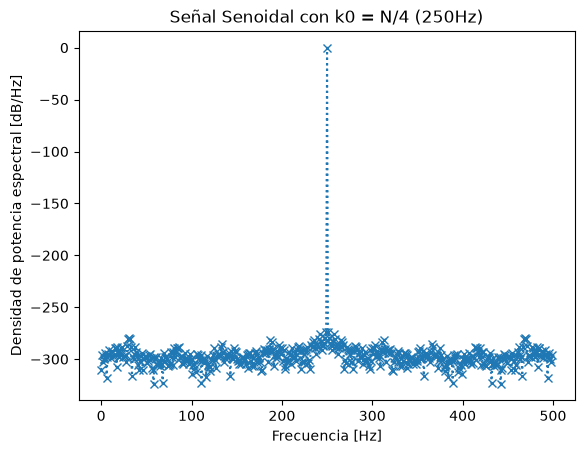

In [15]:
tt,x1 = lib.seno_con_k(np.sqrt(2), N/4, fs/N, N, fs)
ww,spec_t1,spec_t1f = lib.spectometer(x1, N, fs, np.sqrt(2))

plt.figure(1)
plt.title("Señal Senoidal con k0 = N/4 (250Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de potencia espectral [dB/Hz]")
plt.plot(ww,spec_t1, ":x")

El espectro corresponde a una senoidal con frecuencia de 250Hz. El dominio en la frecuencia termina en Nyquist. A partir de ahí, estan las componentes conjugadas y no tienen importancia en nuestro estudio. A -300dB se encuentra el piso de la transformada.
La transformada la realiza una función implementada para la materia. 

In [16]:
def spectometer (signal,n,fs,ref):
    ww = np.arange(start = 0, stop = fs/2, step = fs/n)
    #transformo la señal
    trafo_signal_N = scfft.fft(signal,n)
    trafo_signal = 1/(n) * trafo_signal_N[:n//2]
    #doy modulo y fase
    modulo_trafo_signal = np.abs(2*trafo_signal)
    fase_trafo_signal = np.angle(trafo_signal)
    modulo_db = 20 * np.log10(modulo_trafo_signal/ref)
    return ww,modulo_db,fase_trafo_signal

Para una frecuencia con  $K_0$ entero, el espectro no presenta ninguna particularidad. No hay agregado ningun desplazamiento mínimo en la frecuencia, por lo que el espectro tiene un aspecto esperable para un unico seno. 

Se verifica la potencia por parseval:

In [17]:
potencia1 = (1/N**2)*np.sum(np.abs(scfft.fft(x1,N))**2)
print(potencia1)

1.0


Es la potencia del seno, calculada por parseval. No hay diferencia con definido para la señal.

### $K_0 = \frac{N}{4} + 0.25$ 

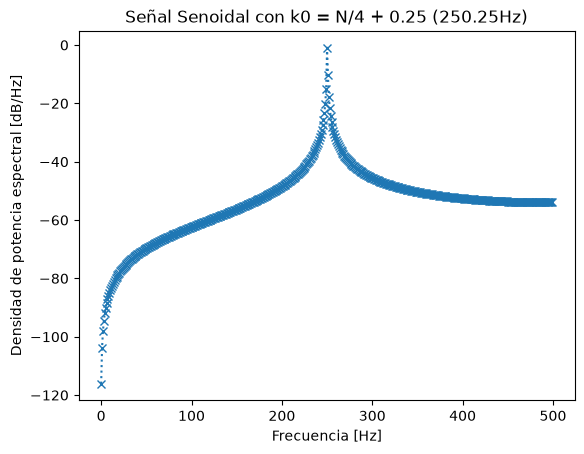

In [18]:
tt,x2 = lib.seno_con_k(np.sqrt(2), N/4 + 0.25, fs/N, N, fs)
ww,spec_t2,spec_t2f = lib.spectometer(x2, N, fs, np.sqrt(2))

plt.figure(2)
plt.title("Señal Senoidal con k0 = N/4 + 0.25 (250.25Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de potencia espectral [dB/Hz]")
plt.plot(ww,spec_t2, ":x")

El espectro corresponde a una senoidal con frecuencia de 250,25Hz. Un incremento en el orden de las decimas de Hz produjo que el piso del espectro se levantara y tenga una forma mucho mas curva, tendiendo a los -120dB en bajas frecuencias. Siendo que la frecuencia se corrió tan poco, lo que se ven son los puntos donde la Sinc de la boxcar y el seno se estan encontrando. La ventana implicita mantiene su posición pero corremos ligeramente la señal y los puntos donde se cruzan (los bins se mantienen en posición) ocurren mucho mas alto en amplitud. Esto es el desparramo espectral. 

Se verifica la potencia por parseval:

In [19]:
potencia2 = (1/N**2)*np.sum(np.abs(scfft.fft(x2,N))**2)
print(potencia2)

0.9989999999999993


La diferencia con el seno a k0 = N/4 se puede deber a que las muestras del espectro no son simétricas alrededor de la delta que le corresponde a la señal, esto debido al desplazamiento de la señal con respecto a la ventana. Lo que se vé en el espectro, sin embargo, es que toda la potencia ahora no se concentra solo en el delta de la frecuencia de la seno, sino que se mueve al resto del espectro.

### $K_0 = \frac{N}{4}$ + 0.5

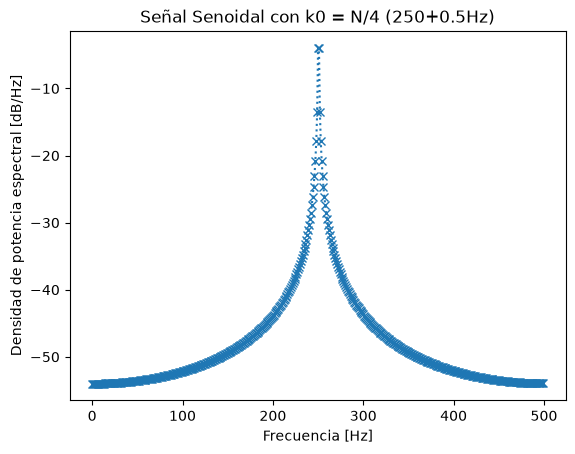

In [20]:
tt,x3 = lib.seno_con_k(np.sqrt(2), N/4 + 0.5, fs/N, N, fs)
ww,spec_t3,spec_t3f = lib.spectometer(x3, N, fs, np.sqrt(2))

plt.figure(3)
plt.title("Señal Senoidal con k0 = N/4 (250+0.5Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de potencia espectral [dB/Hz]")
plt.plot(ww,spec_t3, ":x")

El espectro corresponde a una senoidal con frecuencia de 250,5Hz. Un incremento en el orden de las decimas de Hz produjo que el piso del espectro se levantara y tenga una forma mucho mas curva, tendiendo a los 50dB en ambos lados del pico de amplitud. Siendo que la frecuencia se corrió tan poco, lo que se ven son los puntos donde la Sinc de la boxcar y el seno se estan encontrando. La ventana implicita mantiene su posición pero corremos ligeramente la señal y los puntos donde se cruzan (los bins se mantienen en posición) ocurren mucho mas alto en amplitud. Comparado a la señal anterior, como el aumento de los lobulos de la Sinc no es lineal, el piso del espectro sube mucho menos que con el aumento de 0Hz a 25mHz. Nuevamente, esto es el desparramo espectral.

Se verifica la potencia por parseval:

In [21]:
potencia3 = (1/N**2)*np.sum(np.abs(scfft.fft(x3,N))**2)
print(potencia3)

1.0000000000000004


La diferencia con el seno a k0 = N/4 se puede deber a que las muestras del espectro no son simétricas alrededor de la delta que le corresponde a la señal, esto debido al desplazamiento de la señal con respecto a la ventana. y como la frecuencia es un poco mas grande que a K0 = N/4 + 0.5, mayor porción de señal que entra en la ventana, cambiando los valores que tomen las muestras, dando otro resultado de potencia (viendo a los decimales). Lo que se vé en el espectro, sin embargo, es que toda la potencia ahora no se concentra solo en el delta de la frecuencia de la seno, sino que se mueve al resto del espectro.

### Generación de espectros de densidad de potencia de senoidales, analisis con zero padding

Se agregan 9000 ceros a cada una de las señales estudiadas.

### $K_0 = \frac{N}{4}$ 

(230.0, 270.0)

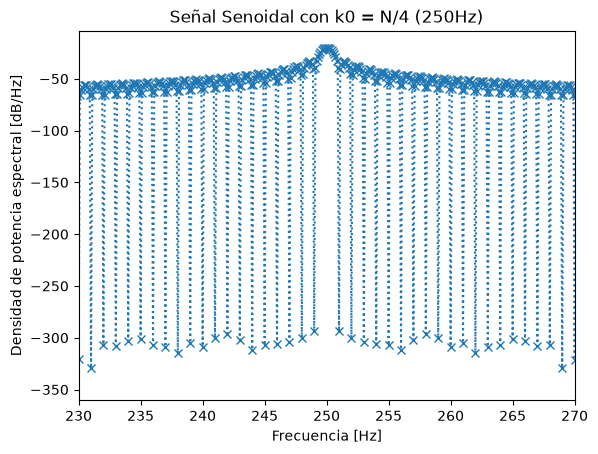

In [31]:
x1_padding = np.zeros(10*N)
x1_padding[0:N] = x1
ww1,spec_t1p,spec_t1pf = lib.spectometer(x1_padding, 10*N, fs, np.sqrt(2))
plt.figure(4)
plt.title("Señal Senoidal con k0 = N/4 (250Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de potencia espectral [dB/Hz]")
plt.plot(ww1,spec_t1p, ":x")
plt.xlim(230*fs/N,270*fs/N) #agregado directamente al notebook para apreciar el efecto del zero padding

El zero padding incrementa la resolución espectral al depender del número de muestras. Con los 9000 ceros agregados, ahora hay 10000 muestras de la señal, con la misma frecuencia de muestreo. La resolución del espectro aumenta. Se puede apreciar la Sinc(w) que corresponde a la transformada de la ventana. En la señal original, cada bin coincidia con la transformada de la seno, pero con la resolución tan alta, se estan tomando muestras de la transformada de la Sinc(w) y no solo de la transformada del seno. Los puntos donde hay coincidencia con los bins para la resolución espectral original, se ven los puntos correspondientes al fondo de la transformada. Esos puntos son los productos de la senoidal por la ventana en frecuencia.

### $K_0 = \frac{N}{4} + 0.25$ 

(230.0, 270.0)

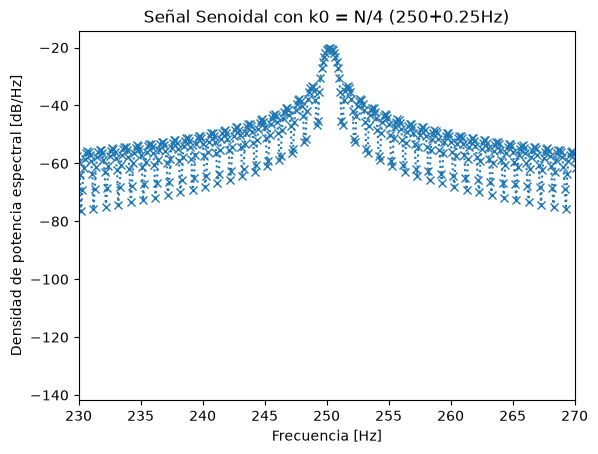

In [30]:
x2_padding = np.zeros(10*N)
x2_padding[0:N] = x2
ww2,spec_t2p,spec_t2pf = lib.spectometer(x2_padding, 10*N, fs, np.sqrt(2))
plt.figure(5)
plt.title("Señal Senoidal con k0 = N/4 (250+0.25Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de potencia espectral [dB/Hz]")
plt.plot(ww2,spec_t2p, ":x")
plt.xlim(230*fs/N,270*fs/N) #agregado directamente al notebook para apreciar el efecto del zero padding

El zero padding incrementa la resolución espectral al depender del número de muestras. Con los 9000 ceros agregados, ahora hay 10000 muestras de la señal, con la misma frecuencia de muestreo. Ahora, si bien se nota la sinc(w), los puntos que se muestran en cada bin estan desplazados ligeramente en frecuencia, 0.25Hz. Esto es lo que se ve en el desparramo espectral, y lo que hace subir el piso de la transformada.

### $K_0 = \frac{N}{4}$ + 0.5

(230.0, 270.0)

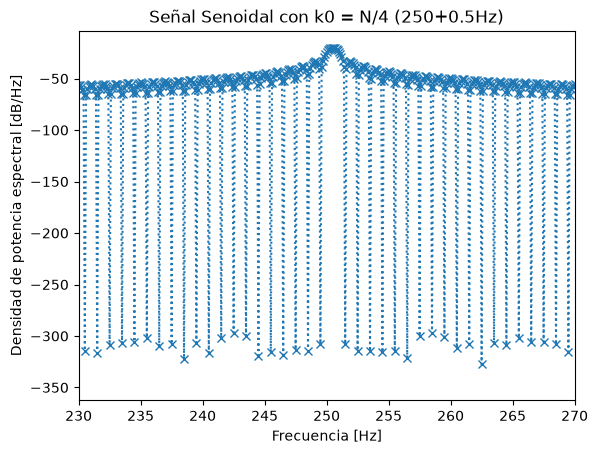

In [32]:
x3_padding = np.zeros(10*N)
x3_padding[0:N] = x3
ww3,spec_t3p,spec_t3pf = lib.spectometer(x3_padding, 10*N, fs, np.sqrt(2))
plt.figure(6)
plt.title("Señal Senoidal con k0 = N/4 (250+0.5Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de potencia espectral [dB/Hz]")
plt.plot(ww3,spec_t3p, ":x")
plt.xlim(230*fs/N,270*fs/N) #agregado directamente al notebook para apreciar el efecto del zero padding

El zero padding incrementa la resolución espectral al depender del número de muestras. Con los 9000 ceros agregados, ahora hay 10000 muestras de la señal, con la misma frecuencia de muestreo. Esta señal tambien esta desplazada ligeramente en frecuencia, 0.5Hz. En lugar de tomar los bins en el fondo del espectro, toma los puntos que corresponden a los máximos de los lobulos, subiendo el piso de la transformada hasta los -50dB comparado a la señal con el desplazamiento en 0.25Hz. 

### Conclusiones

Al desplazar un número no entero de Hz en frecuencia una señal, ocurre el fenómeno de desparramo espectral, donde la energia de la señal deja de concentrarse en el delta correspondiente en el espectro, y pasa a distribuirse en él. Esto se debe a que la transformada se realiza no solo en una señal, sino tambien en una ventana. Esta ventana toma datos de la señal y son los usados para llevar a cabo la transformada. Lo que vemos como la señal a analizar es la convolución circular entre una ventana y la señal deseada. Esta convolución es un producto en frecuencia, y dicho producto es lo que se aprecia en el espectro. Todos los puntos que caen en los bins del espectro son los productos punto a punto de la ventana (que se transforma en una Sinc(w)) por una delta (la transformada del seno para frecuencias positivas).

Esta ventana puede verse utilizando el zero padding, agregando ceros al final de la señal a analizar. Al aumentar la cantidad de puntos dentro de la ventana, aumenta la resolución espectral, y con ese aumento, los bins del espectro aumentan, permitiendo ver mas de los productos entre el seno y la ventana. 

En los gráficos presentados, a fs = 1 Hz, se ve como los puntos de la transformada son solo algunos de los obtenidos en los gráficos de fs = 1/10 Hz. Para k0 = N/4 son los puntos que coinciden con los que unen los lóbulos de la Sinc(w). Para K0 = N/4 + 0.25, los puntos son los de las curvas de los lóbulos, y para k0 = N/4 + 0.5 son los picos de los lóbulos.


### Referencias

* Holton, Thomas (2021). Digital Signal Processing - Principles and Applications. Cambridge University Press